# RANDOM FOREST
Author: Justin Joon Lee

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from scipy.fftpack import fft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

Random Forest Accuracy: 0.5426008968609866
Random Forest Classification Report:
              precision    recall  f1-score   support

           A       0.69      0.84      0.76        32
           B       0.45      0.39      0.42        36
           C       0.58      0.39      0.47        46
           D       0.49      0.50      0.49        38
           E       0.53      0.64      0.58        42
           F       0.50      0.55      0.52        29

    accuracy                           0.54       223
   macro avg       0.54      0.55      0.54       223
weighted avg       0.54      0.54      0.53       223

Confusion Matrix:
[[27  1  1  0  1  2]
 [ 2 14  5  5  8  2]
 [ 5  5 18  8  3  7]
 [ 0  6  3 19  9  1]
 [ 0  4  3  4 27  4]
 [ 5  1  1  3  3 16]]


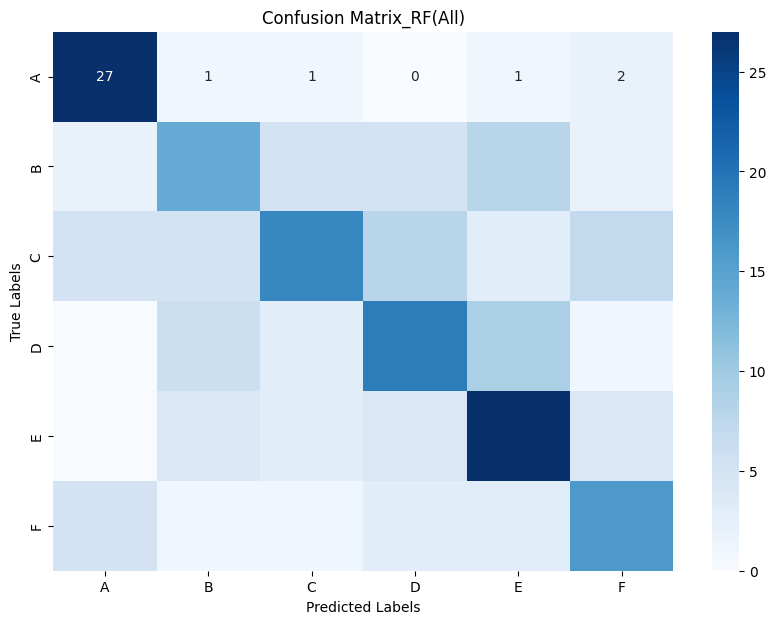

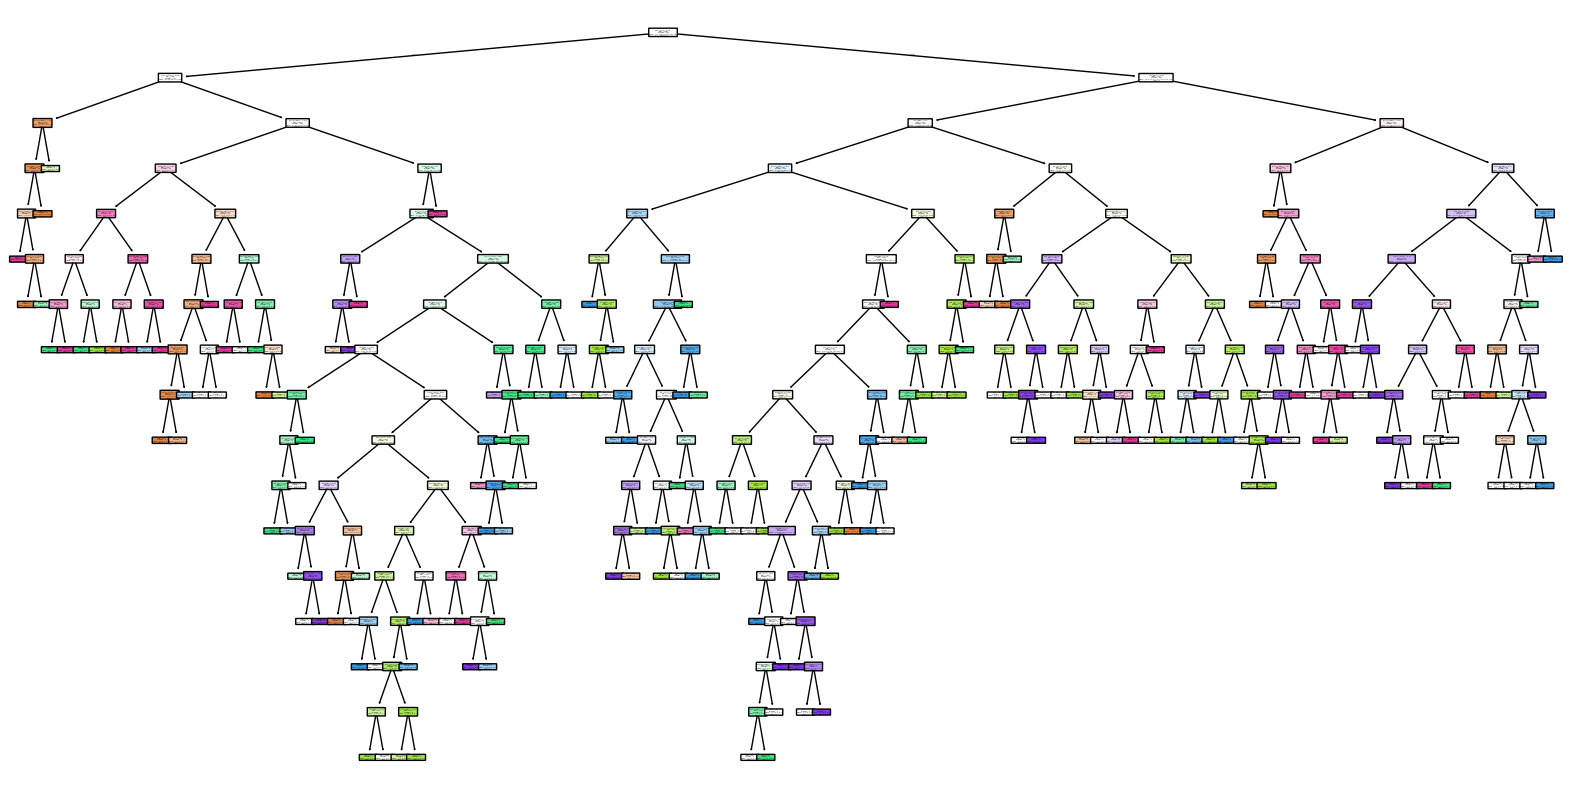

In [ ]:
###########################
#  4-1) For every motion  #
###########################

warnings.filterwarnings("ignore", category=FutureWarning)

directory_path = './data/EMG_data'

all_files = glob.glob(os.path.join(directory_path, "*.csv"))

dataframes = []

for file in all_files:
    try:
        df = pd.read_csv(file)
        operation = os.path.basename(file).split('_')[0]  
        df['operation'] = operation
        dataframes.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if not dataframes:
    raise ValueError("No valid dataframes to concatenate.")

all_data = pd.concat(dataframes, ignore_index=True)

if 'Unnamed: 0' in all_data.columns:
    all_data = all_data.drop(columns=['Unnamed: 0'])

#### Feature Extraction ####

def extract_features(segment):
    features = {}
    # Time domain 
    features['mean_raw1'] = segment['raw1'].mean()
    features['std_raw1'] = segment['raw1'].std()
    features['max_raw1'] = segment['raw1'].max()
    features['min_raw1'] = segment['raw1'].min()
    
    features['mean_raw2'] = segment['raw2'].mean()
    features['std_raw2'] = segment['raw2'].std()
    features['max_raw2'] = segment['raw2'].max()
    features['min_raw2'] = segment['raw2'].min()
    
    features['mean_raw3'] = segment['raw3'].mean()
    features['std_raw3'] = segment['raw3'].std()
    features['max_raw3'] = segment['raw3'].max()
    features['min_raw3'] = segment['raw3'].min()

    features['rms_raw1'] = np.sqrt(np.mean(segment['raw1']**2))
    features['rms_raw2'] = np.sqrt(np.mean(segment['raw2']**2))
    features['rms_raw3'] = np.sqrt(np.mean(segment['raw3']**2))
    
    features['zcr_raw1'] = ((segment['raw1'][:-1] * segment['raw1'][1:]) < 0).sum()
    features['zcr_raw2'] = ((segment['raw2'][:-1] * segment['raw2'][1:]) < 0).sum()
    features['zcr_raw3'] = ((segment['raw3'][:-1] * segment['raw3'][1:]) < 0).sum()
    
    features['skewness_raw1'] = segment['raw1'].skew()
    features['skewness_raw2'] = segment['raw2'].skew()
    features['skewness_raw3'] = segment['raw3'].skew()
    
    features['kurtosis_raw1'] = segment['raw1'].kurtosis()
    features['kurtosis_raw2'] = segment['raw2'].kurtosis()
    features['kurtosis_raw3'] = segment['raw3'].kurtosis()
    
    features['mad_raw1'] = np.mean(np.abs(segment['raw1'] - segment['raw1'].mean()))
    features['mad_raw2'] = np.mean(np.abs(segment['raw2'] - segment['raw2'].mean()))
    features['mad_raw3'] = np.mean(np.abs(segment['raw3'] - segment['raw3'].mean()))
    
    # Frequency domain(FFT)
    freqs_raw1 = np.abs(fft(segment['raw1']))[:len(segment)//2]
    freqs_raw2 = np.abs(fft(segment['raw2']))[:len(segment)//2]
    freqs_raw3 = np.abs(fft(segment['raw3']))[:len(segment)//2]
    
    features['fft_mean_raw1'] = np.mean(freqs_raw1)
    features['fft_std_raw1'] = np.std(freqs_raw1)
    features['fft_max_raw1'] = np.max(freqs_raw1)
    
    features['fft_mean_raw2'] = np.mean(freqs_raw2)
    features['fft_std_raw2'] = np.std(freqs_raw2)
    features['fft_max_raw2'] = np.max(freqs_raw2)
    
    features['fft_mean_raw3'] = np.mean(freqs_raw3)
    features['fft_std_raw3'] = np.std(freqs_raw3)
    features['fft_max_raw3'] = np.max(freqs_raw3)
    
    return features

# Extract features from each segment
feature_list = []
target_list = []

segment_size = 400 
for i in range(0, len(all_data), segment_size):
    segment = all_data.iloc[i:i+segment_size]
    if len(segment) < segment_size:
        continue
    features = extract_features(segment)
    feature_list.append(features)
    target_list.append(segment['operation'].iloc[0])

# Create a dataframe from the extracted features and targets
features_df = pd.DataFrame(feature_list)
target_df = pd.Series(target_list)


X = features_df
y = target_df

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameters
model = RandomForestClassifier(
    n_estimators = 700, 
    max_depth = 25, 
    min_samples_split = 3, 
    min_samples_leaf = 2, 
    random_state = 42 
    ) 

#### Training ####

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 1. Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"Random Forest Accuracy: {accuracy}")
print("Random Forest Classification Report:")
print(report)

# 2. Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix_RF(All)')
plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=features_df.columns, class_names=le.classes_, filled=True, rounded=True)
plt.show()

Random Forest Accuracy: 0.5978260869565217
Random Forest Classification Report:
              precision    recall  f1-score   support

           A       0.76      0.84      0.79        37
           B       0.54      0.45      0.49        29
           C       0.60      0.36      0.45        42
           D       0.49      0.76      0.60        34
           F       0.61      0.60      0.60        42

    accuracy                           0.60       184
   macro avg       0.60      0.60      0.59       184
weighted avg       0.60      0.60      0.59       184

Confusion Matrix:
[[31  2  1  0  3]
 [ 2 13  4  8  2]
 [ 3  3 15 12  9]
 [ 0  4  2 26  2]
 [ 5  2  3  7 25]]


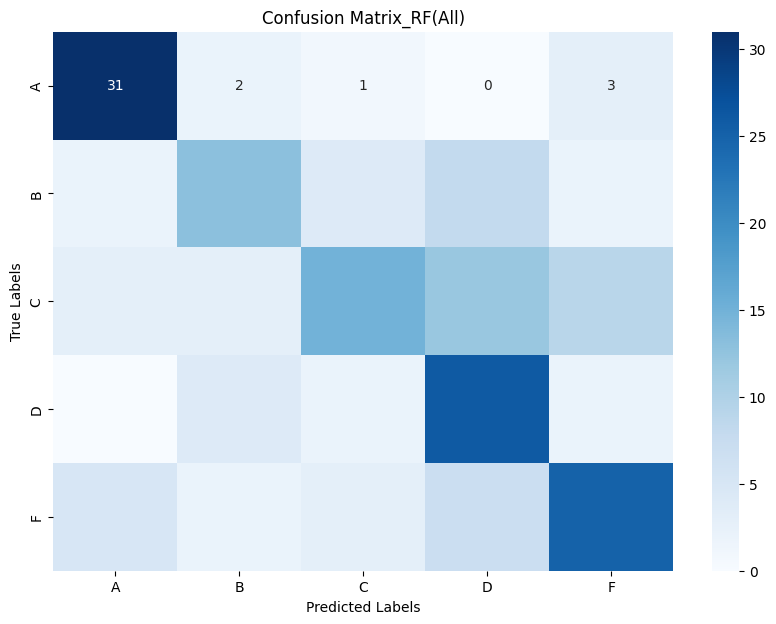

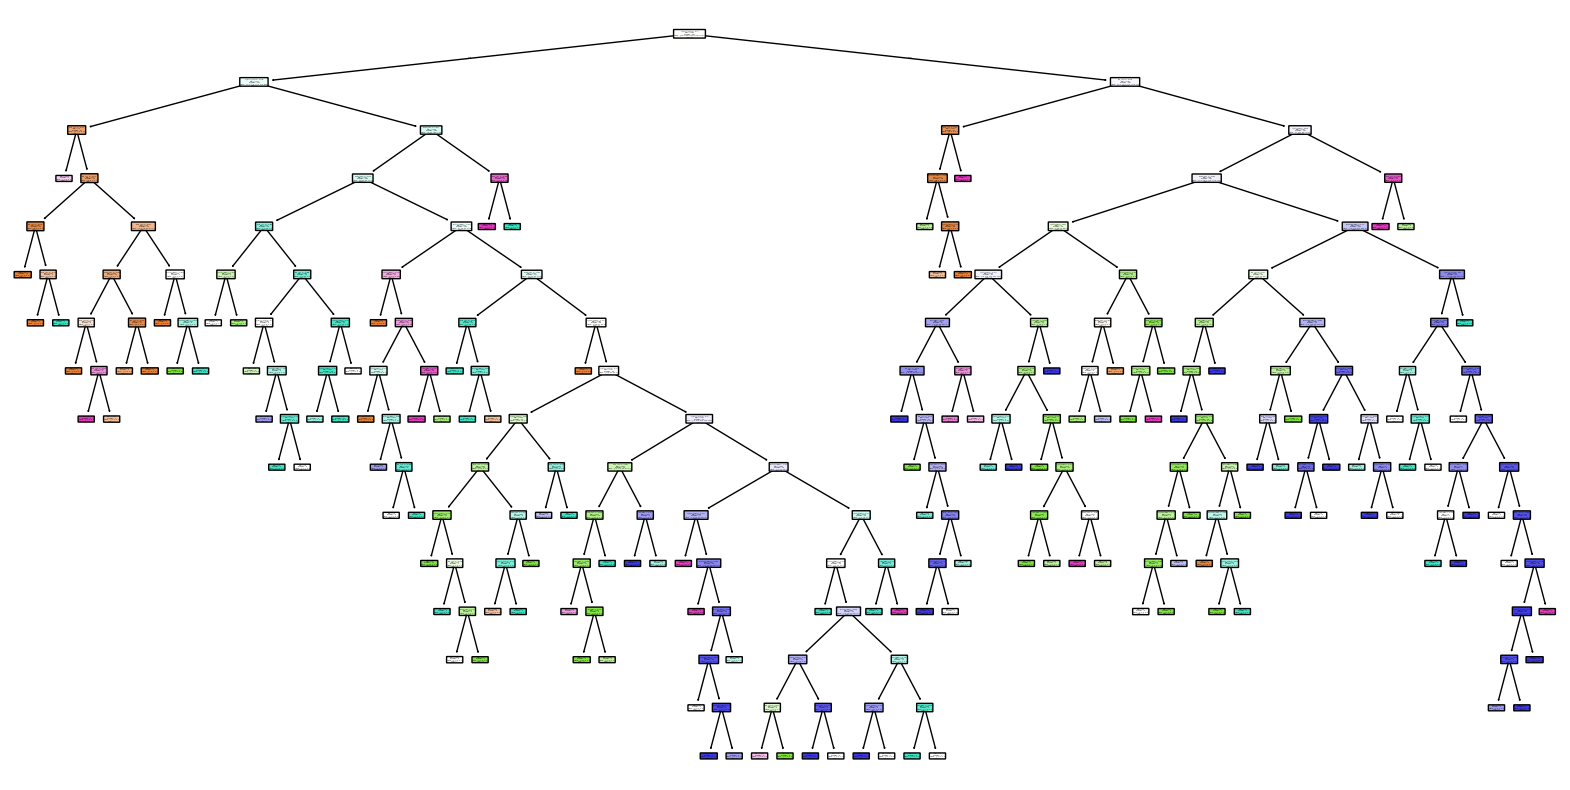

In [ ]:
###########################
#  4-2) A,B,C,D,F Motion  #
###########################

warnings.filterwarnings("ignore", category=FutureWarning)

directory_path = './data/data_ABCDF'

all_files = glob.glob(os.path.join(directory_path, "*.csv"))

dataframes = []

for file in all_files:
    try:
        df = pd.read_csv(file)
        operation = os.path.basename(file).split('_')[0]  
        df['operation'] = operation
        dataframes.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if not dataframes:
    raise ValueError("No valid dataframes to concatenate.")

all_data = pd.concat(dataframes, ignore_index=True)

if 'Unnamed: 0' in all_data.columns:
    all_data = all_data.drop(columns=['Unnamed: 0'])

#### Feature Extraction ####

def extract_features(segment):
    features = {}
    # Time domain 
    features['mean_raw1'] = segment['raw1'].mean()
    features['std_raw1'] = segment['raw1'].std()
    features['max_raw1'] = segment['raw1'].max()
    features['min_raw1'] = segment['raw1'].min()
    
    features['mean_raw2'] = segment['raw2'].mean()
    features['std_raw2'] = segment['raw2'].std()
    features['max_raw2'] = segment['raw2'].max()
    features['min_raw2'] = segment['raw2'].min()
    
    features['mean_raw3'] = segment['raw3'].mean()
    features['std_raw3'] = segment['raw3'].std()
    features['max_raw3'] = segment['raw3'].max()
    features['min_raw3'] = segment['raw3'].min()

    features['rms_raw1'] = np.sqrt(np.mean(segment['raw1']**2))
    features['rms_raw2'] = np.sqrt(np.mean(segment['raw2']**2))
    features['rms_raw3'] = np.sqrt(np.mean(segment['raw3']**2))
    
    features['zcr_raw1'] = ((segment['raw1'][:-1] * segment['raw1'][1:]) < 0).sum()
    features['zcr_raw2'] = ((segment['raw2'][:-1] * segment['raw2'][1:]) < 0).sum()
    features['zcr_raw3'] = ((segment['raw3'][:-1] * segment['raw3'][1:]) < 0).sum()
    
    features['skewness_raw1'] = segment['raw1'].skew()
    features['skewness_raw2'] = segment['raw2'].skew()
    features['skewness_raw3'] = segment['raw3'].skew()
    
    features['kurtosis_raw1'] = segment['raw1'].kurtosis()
    features['kurtosis_raw2'] = segment['raw2'].kurtosis()
    features['kurtosis_raw3'] = segment['raw3'].kurtosis()
    
    features['mad_raw1'] = np.mean(np.abs(segment['raw1'] - segment['raw1'].mean()))
    features['mad_raw2'] = np.mean(np.abs(segment['raw2'] - segment['raw2'].mean()))
    features['mad_raw3'] = np.mean(np.abs(segment['raw3'] - segment['raw3'].mean()))
    
    # Frequency domain(FFT)
    freqs_raw1 = np.abs(fft(segment['raw1']))[:len(segment)//2]
    freqs_raw2 = np.abs(fft(segment['raw2']))[:len(segment)//2]
    freqs_raw3 = np.abs(fft(segment['raw3']))[:len(segment)//2]
    
    features['fft_mean_raw1'] = np.mean(freqs_raw1)
    features['fft_std_raw1'] = np.std(freqs_raw1)
    features['fft_max_raw1'] = np.max(freqs_raw1)
    
    features['fft_mean_raw2'] = np.mean(freqs_raw2)
    features['fft_std_raw2'] = np.std(freqs_raw2)
    features['fft_max_raw2'] = np.max(freqs_raw2)
    
    features['fft_mean_raw3'] = np.mean(freqs_raw3)
    features['fft_std_raw3'] = np.std(freqs_raw3)
    features['fft_max_raw3'] = np.max(freqs_raw3)
    
    return features

# Extract features from each segment
feature_list = []
target_list = []

segment_size = 400 
for i in range(0, len(all_data), segment_size):
    segment = all_data.iloc[i:i+segment_size]
    if len(segment) < segment_size:
        continue
    features = extract_features(segment)
    feature_list.append(features)
    target_list.append(segment['operation'].iloc[0])

# Create a dataframe from the extracted features and targets
features_df = pd.DataFrame(feature_list)
target_df = pd.Series(target_list)


X = features_df
y = target_df

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameters
model = RandomForestClassifier(
    n_estimators = 700, 
    max_depth = 25, 
    min_samples_split = 3, 
    min_samples_leaf = 2, 
    random_state = 42 
    ) 

#### Training ####

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 1. Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"Random Forest Accuracy: {accuracy}")
print("Random Forest Classification Report:")
print(report)

# 2. Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix_RF(All)')
plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=features_df.columns, class_names=le.classes_, filled=True, rounded=True)
plt.show()

Random Forest Accuracy: 0.7289719626168224
Random Forest Classification Report:
              precision    recall  f1-score   support

           A       0.78      0.69      0.74        36
           C       0.68      0.91      0.78        33
           F       0.74      0.61      0.67        38

    accuracy                           0.73       107
   macro avg       0.74      0.74      0.73       107
weighted avg       0.74      0.73      0.72       107

Confusion Matrix:
[[25  4  7]
 [ 2 30  1]
 [ 5 10 23]]


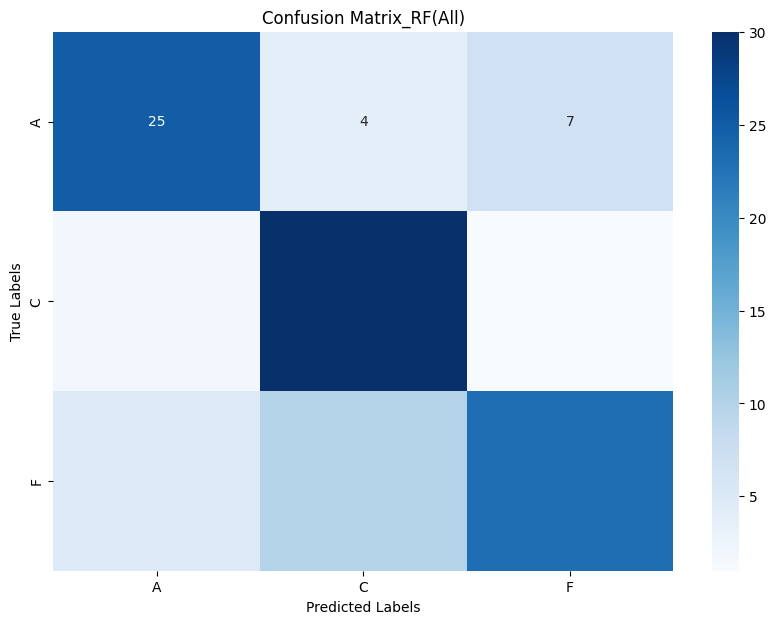

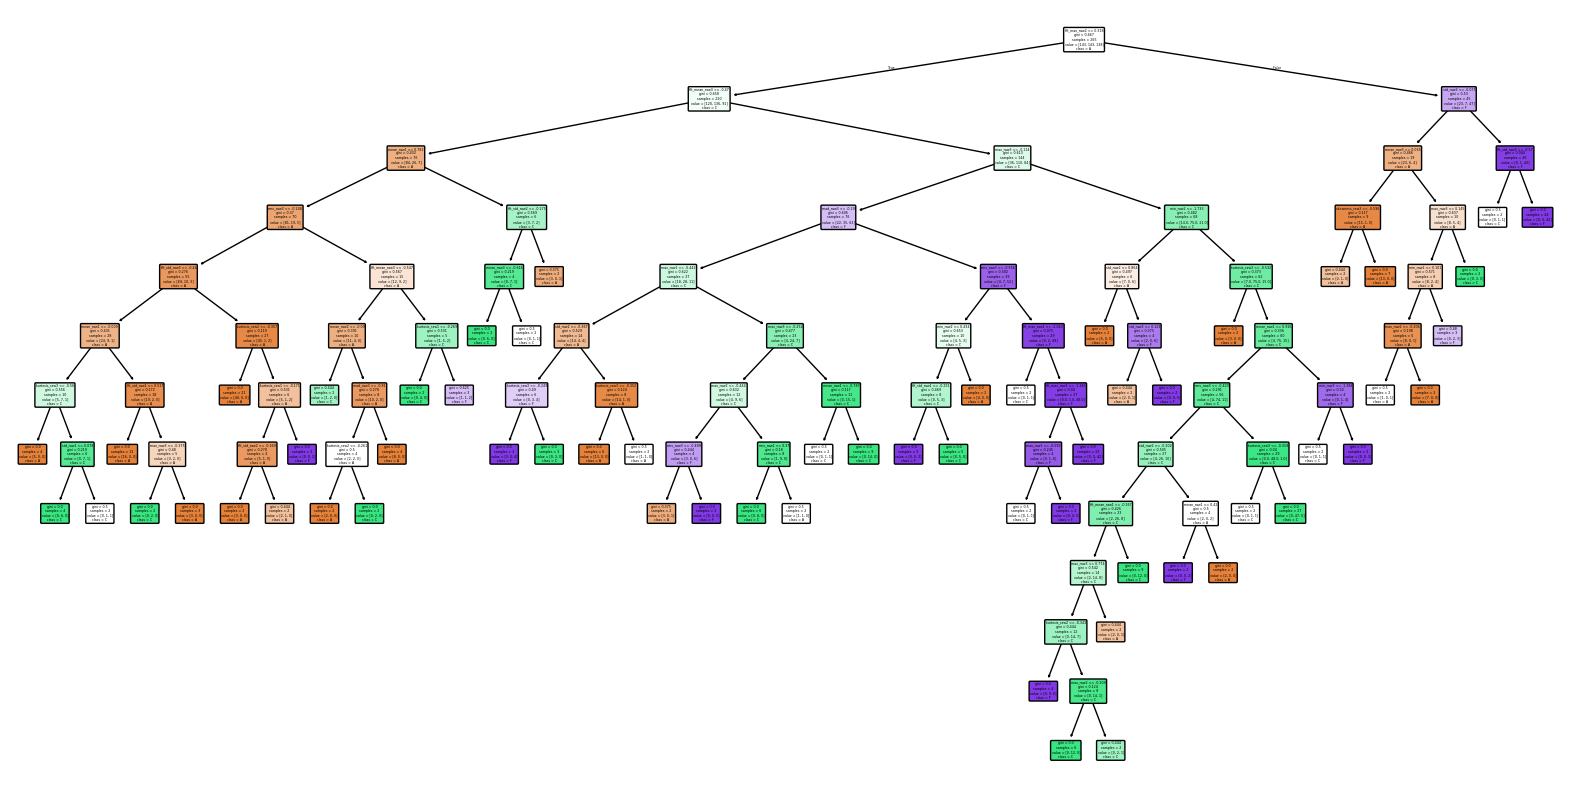

In [ ]:
#######################
#  4-3) A,C,F Motion  #
#######################

warnings.filterwarnings("ignore", category=FutureWarning)

directory_path = './data/data_ACF'

all_files = glob.glob(os.path.join(directory_path, "*.csv"))

dataframes = []

for file in all_files:
    try:
        df = pd.read_csv(file)
        operation = os.path.basename(file).split('_')[0]  
        df['operation'] = operation
        dataframes.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if not dataframes:
    raise ValueError("No valid dataframes to concatenate.")

all_data = pd.concat(dataframes, ignore_index=True)

if 'Unnamed: 0' in all_data.columns:
    all_data = all_data.drop(columns=['Unnamed: 0'])

#### Feature Extraction ####

def extract_features(segment):
    features = {}
    # Time domain 
    features['mean_raw1'] = segment['raw1'].mean()
    features['std_raw1'] = segment['raw1'].std()
    features['max_raw1'] = segment['raw1'].max()
    features['min_raw1'] = segment['raw1'].min()
    
    features['mean_raw2'] = segment['raw2'].mean()
    features['std_raw2'] = segment['raw2'].std()
    features['max_raw2'] = segment['raw2'].max()
    features['min_raw2'] = segment['raw2'].min()
    
    features['mean_raw3'] = segment['raw3'].mean()
    features['std_raw3'] = segment['raw3'].std()
    features['max_raw3'] = segment['raw3'].max()
    features['min_raw3'] = segment['raw3'].min()

    features['rms_raw1'] = np.sqrt(np.mean(segment['raw1']**2))
    features['rms_raw2'] = np.sqrt(np.mean(segment['raw2']**2))
    features['rms_raw3'] = np.sqrt(np.mean(segment['raw3']**2))
    
    features['zcr_raw1'] = ((segment['raw1'][:-1] * segment['raw1'][1:]) < 0).sum()
    features['zcr_raw2'] = ((segment['raw2'][:-1] * segment['raw2'][1:]) < 0).sum()
    features['zcr_raw3'] = ((segment['raw3'][:-1] * segment['raw3'][1:]) < 0).sum()
    
    features['skewness_raw1'] = segment['raw1'].skew()
    features['skewness_raw2'] = segment['raw2'].skew()
    features['skewness_raw3'] = segment['raw3'].skew()
    
    features['kurtosis_raw1'] = segment['raw1'].kurtosis()
    features['kurtosis_raw2'] = segment['raw2'].kurtosis()
    features['kurtosis_raw3'] = segment['raw3'].kurtosis()
    
    features['mad_raw1'] = np.mean(np.abs(segment['raw1'] - segment['raw1'].mean()))
    features['mad_raw2'] = np.mean(np.abs(segment['raw2'] - segment['raw2'].mean()))
    features['mad_raw3'] = np.mean(np.abs(segment['raw3'] - segment['raw3'].mean()))
    
    # Frequency domain(FFT)
    freqs_raw1 = np.abs(fft(segment['raw1']))[:len(segment)//2]
    freqs_raw2 = np.abs(fft(segment['raw2']))[:len(segment)//2]
    freqs_raw3 = np.abs(fft(segment['raw3']))[:len(segment)//2]
    
    features['fft_mean_raw1'] = np.mean(freqs_raw1)
    features['fft_std_raw1'] = np.std(freqs_raw1)
    features['fft_max_raw1'] = np.max(freqs_raw1)
    
    features['fft_mean_raw2'] = np.mean(freqs_raw2)
    features['fft_std_raw2'] = np.std(freqs_raw2)
    features['fft_max_raw2'] = np.max(freqs_raw2)
    
    features['fft_mean_raw3'] = np.mean(freqs_raw3)
    features['fft_std_raw3'] = np.std(freqs_raw3)
    features['fft_max_raw3'] = np.max(freqs_raw3)
    
    return features

# Extract features from each segment
feature_list = []
target_list = []

segment_size = 400 
for i in range(0, len(all_data), segment_size):
    segment = all_data.iloc[i:i+segment_size]
    if len(segment) < segment_size:
        continue
    features = extract_features(segment)
    feature_list.append(features)
    target_list.append(segment['operation'].iloc[0])

# Create a dataframe from the extracted features and targets
features_df = pd.DataFrame(feature_list)
target_df = pd.Series(target_list)


X = features_df
y = target_df

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hyperparameters
model = RandomForestClassifier(
    n_estimators = 700, 
    max_depth = 25, 
    min_samples_split = 3, 
    min_samples_leaf = 2, 
    random_state = 42 
    ) 

#### Training ####

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 1. Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"Random Forest Accuracy: {accuracy}")
print("Random Forest Classification Report:")
print(report)

# 2. Generate and display the Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix_RF(All)')
plt.show()

from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=features_df.columns, class_names=le.classes_, filled=True, rounded=True)
plt.show()